<a href="https://colab.research.google.com/github/semmatoninn/CHE1148_MOFs_AtomicWizards/blob/main/MOFs_E3GNN__AtomicWizards_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHE1148 Direct Air Capture of $CO_2$ using MOFs
## Rija Ansari, Uyen (Emma) Hua, Miguel Freyermuth
### Predicting $CO_2$ Adsorption in Metal–Organic Frameworks with Equivariant Graph Neural Networks


## Package Installation

Before we begin lets install the proper packages we will need for GNN

1. Select T4 GPU (if using Colab Pro use A100 GPU)
2. Comment in 4 install cells below
3. Once installed restart runtime and run the import cell

In [1]:
# Install everything, then RESTART KERNEL before continuing
!pip uninstall -y torch torchvision torchaudio torch_scatter torch_sparse torch_cluster torch_spline_conv torch_geometric
!pip install torch==2.2.2 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q

!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.2.2+cu121.html -q
!pip install torch_geometric ase -q

!pip install "numpy>=2.0,<2.1" -q

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 144.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 115.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 117.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 138.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━

## Load and Convert Data

Restart runtime and run the remainder of the notebook:

In [2]:
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

In [3]:
# Cell 2 — run ONLY after restarting kernel
import torch, torch_geometric, torch_scatter, torch_sparse, torch_cluster, ase
print(torch.__version__)
print(torch.version.cuda)
print("Everything loaded correctly!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

2.2.2+cu121
12.1
Everything loaded correctly!


In [1]:
import torch
import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster
import ase

#import torch_scatter


print("Everything installed correctly!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

Everything installed correctly!


In [2]:
!git clone https://github.com/semmatoninn/CHE1148_MOFs_AtomicWizards/

Cloning into 'CHE1148_MOFs_AtomicWizards'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 92 (delta 42), reused 13 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 29.04 MiB | 6.33 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [3]:
!ls

CHE1148_MOFs_AtomicWizards  sample_data


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import glob
from ase.io import read
from torch_geometric.data import Data
from torch_geometric.nn import radius_graph, GCNConv, global_mean_pool
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split

In [5]:
print(os.listdir('CHE1148_MOFs_AtomicWizards/'))

['mof_split.csv', 'graph_data_cache.pt', 'MOFs_E3GNN__AtomicWizards_Final.ipynb', 'graph_data_cache3.pt', 'graph_data_cache2.pt', 'CO2_labels_per_MOF.csv', 'mof_cif_194.zip', 'sample_metadata.csv', 'EGNN_FullStructure_LocalHost.ipynb', '.git', 'MOFs_E3GNN__AtomicWizards.ipynb', 'Final_EGNN_FullStructure.ipynb', 'Configuration_level_EGNN_FullStructure.ipynb', 'preprocess_split.py', 'EGNN_FullStructure.ipynb', 'README.md']


### Unzip MOF CIF Files

In [6]:
!unzip -q CHE1148_MOFs_AtomicWizards/mof_cif_194.zip -d CHE1148_MOFs_AtomicWizards/

### Load CO2 Labels from CSV

In [7]:
#read the CO2 labels .csv file
df = pd.read_csv('CHE1148_MOFs_AtomicWizards/CO2_labels_per_MOF.csv')
df

,mof_name,mof_type,nco2_max,eads_min,eads_mean,n_configs
0,ADOBEB_charged,pristine,1,-0.146386,-0.030648,699
1,AJAKON,pristine,1,-0.218210,-0.088205,717
2,ANUGEW_deen_33,functionalized,1,-0.272465,0.020770,253
3,AQUCOG_0.11_0_deen_11,functionalized,1,-0.240284,-0.164271,449
4,AQUCOG_0.11_0_dmen_5.5,functionalized,1,-0.151717,-0.075495,286
...,...,...,...,...,...,...
189,ja506357n_si_002_0.12_0,defective,1,-0.323977,-0.188934,866
190,ja5b02897_si_003_0.08_0_en_12,functionalized,1,0.557638,0.664121,668
191,jz4002345_si_002,pristine,1,-0.261281,-0.187379,268
192,jz4002345_si_002_0.08_0,defective,1,-0.240357,-0.169550,508


### Convert CIFs to Graph Data with Labels

Iterate each CIF file to obtain the atomic structure using ASE.

The atomic structure can then be converted to a 'torch_geometric.data.Data'
object.
- nodes represent atoms
- edges represent bonds

The CO2 labels from the CSV file can be added for each unique MOF graph.

Target variable selected is eads_min, representing the strongest adsorption energy, which is the most critical value for ranking and screening MOFs in practical adsorption applications.


In [8]:
# Fast CIF conversion with parallelism + caching
import os, glob, torch
import pandas as pd
import numpy as np
from ase.io import read
from torch_geometric.data import Data
from torch_geometric.nn import radius_graph
from multiprocessing import Pool
from functools import partial
from google.colab import userdata

CACHE_PATH = 'CHE1148_MOFs_AtomicWizards/graph_data_cache.pt'

from ase.io import read
from ase.neighborlist import neighbor_list

def cif_to_graph_data(cif_path, label_dict, cutoff=6.0):
    try:
        atoms = read(cif_path)

        x   = torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long).unsqueeze(1)
        pos = torch.tensor(atoms.get_positions(), dtype=torch.float)

        # PBC-aware neighbor list using ASE
        i, j, d = neighbor_list('ijd', atoms, cutoff=cutoff, self_interaction=False)
        edge_index = torch.tensor(np.vstack([i, j]), dtype=torch.long)
        edge_attr  = torch.tensor(d, dtype=torch.float).unsqueeze(1)  # distance as edge feature

        mof_name = os.path.splitext(os.path.basename(cif_path))[0]
        if mof_name not in label_dict:
            print(f"Warning: no labels for {mof_name}")
            return None

        eads_min, eads_mean = label_dict[mof_name]
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,        # now you have distances as features
            pos=pos,
            #y=torch.tensor([[eads_min, eads_mean]], dtype=torch.float),
            y = torch.tensor([eads_min], dtype = torch.float).unsqueeze(1),
            mof_name=mof_name
        )
        return data

    except Exception as e:
        print(f"Error {cif_path}: {e}")
        return None

To generate the appropriate graphs from the cif files, the data was processed and cached in the repository.

To generate the graphs independently:

- In Github, generate a **Personal Access Token** by going to **GitHub → Settings → Developer settings → Personal access tokens → Tokens (classic)** and creating a new token with the required permissions
- In Colab, store it securely by running `from google.colab import userdata` and saving it with `userdata.set('GITHUB_TOKEN', 'your_token_here')`
- Comment out the below cell and the cached files can then be pushed to an independent clone of the repository.

In [9]:
"""# Run conversion, cache locally AND push to GitHub
import subprocess
from functools import partial
from multiprocessing import get_context
from tqdm import tqdm

cif_directory = 'CHE1148_MOFs_AtomicWizards/mof_cif_194/'
cif_files = glob.glob(os.path.join(cif_directory, '*.cif'))

REPO_DIR   = 'CHE1148_MOFs_AtomicWizards'
CACHE_PATH = f'{REPO_DIR}/graph_data_cache3.pt'

if os.path.exists(CACHE_PATH):
    print("Loading cached graphs from repo...")
    graph_data_list = torch.load(CACHE_PATH)
    print(f"Loaded {len(graph_data_list)} graphs.")

else:
    print(f"Processing {len(cif_files)} CIF files sequentially...")
    label_dict = {
        row['mof_name']: (row['eads_min'], row['eads_mean'])
        for _, row in df.iterrows()
    }

    # Sequential — avoids all multiprocessing deadlock issues on Colab
    graph_data_list = []
    for cif_path in tqdm(cif_files):
        try:
            result = cif_to_graph_data(cif_path, label_dict=label_dict, cutoff=6.0)
            if result is not None:
                graph_data_list.append(result)
        except Exception as e:
            print(f"Error on {cif_path}: {e}")
            continue

    print(f"\nSuccessfully processed {len(graph_data_list)} / {len(cif_files)} graphs.")
    torch.save(graph_data_list, CACHE_PATH)
    print(f"Saved to {CACHE_PATH}")

    # Push to GitHub so this never runs again
    github_token = userdata.get('GITHUB_TOKEN')
    repo_url = f"https://{github_token}@github.com/semmatoninn/CHE1148_MOFs_AtomicWizards.git"

    cmds = [
        ["git", "-C", REPO_DIR, "config", "user.email", "rija.ansari@gmail.com"],
        ["git", "-C", REPO_DIR, "config", "user.name",  "rija-ansari"],
        ["git", "-C", REPO_DIR, "remote", "set-url", "origin", repo_url],
        ["git", "-C", REPO_DIR, "add",    "graph_data_cache3.pt"],
        ["git", "-C", REPO_DIR, "commit", "-m", "Add PBC graph cache with 6A cutoff"],
        ["git", "-C", REPO_DIR, "push",   "origin", "main"],
    ]
    for cmd in cmds:
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"Git error: {result.stderr}")
            break
    else:
        print("Pushed to GitHub successfully.")"""

'# Run conversion, cache locally AND push to GitHub\nimport subprocess\nfrom functools import partial\nfrom multiprocessing import get_context\nfrom tqdm import tqdm\n\ncif_directory = \'CHE1148_MOFs_AtomicWizards/mof_cif_194/\'\ncif_files = glob.glob(os.path.join(cif_directory, \'*.cif\'))\n\nREPO_DIR   = \'CHE1148_MOFs_AtomicWizards\'\nCACHE_PATH = f\'{REPO_DIR}/graph_data_cache3.pt\'\n\nif os.path.exists(CACHE_PATH):\n    print("Loading cached graphs from repo...")\n    graph_data_list = torch.load(CACHE_PATH)\n    print(f"Loaded {len(graph_data_list)} graphs.")\n\nelse:\n    print(f"Processing {len(cif_files)} CIF files sequentially...")\n    label_dict = {\n        row[\'mof_name\']: (row[\'eads_min\'], row[\'eads_mean\'])\n        for _, row in df.iterrows()\n    }\n\n    # Sequential — avoids all multiprocessing deadlock issues on Colab\n    graph_data_list = []\n    for cif_path in tqdm(cif_files):\n        try:\n            result = cif_to_graph_data(cif_path, label_dict=label

In [10]:
# Load preprocessed graphs from repo (no regeneration needed)
CACHE_PATH = 'CHE1148_MOFs_AtomicWizards/graph_data_cache3.pt'

size_mb = os.path.getsize(CACHE_PATH) / 1e6
print(f"Cache size: {size_mb:.1f} MB")
if size_mb > 95:
    print("Warning: file >95MB — consider Git LFS or saving to Google Drive instead.")

graph_data_list = torch.load(CACHE_PATH)
print(f"Loaded {len(graph_data_list)} graphs from repo cache.")


Cache size: 45.3 MB
Loaded 194 graphs from repo cache.


In [11]:
print("\nFirst 3 generated Data objects:")
for i, data_obj in enumerate(graph_data_list[:3]):
    print(f"\nData Object {i+1}:")
    print(f"  MOF Name: {data_obj.mof_name}") # Added to show the new attribute
    print(f"  Number of nodes (atoms): {data_obj.num_nodes}")
    print(f"  Number of edges (bonds): {data_obj.num_edges}")
    print(f"  Node features (x.shape): {data_obj.x.shape}")
    print(f"  Edge index (edge_index.shape): {data_obj.edge_index.shape}")
    print(f"  Positions (pos.shape): {data_obj.pos.shape}")
    print(f"  Labels (y): {data_obj.y}")


First 3 generated Data objects:

Data Object 1:
  MOF Name: FERWAC
  Number of nodes (atoms): 105
  Number of edges (bonds): 5934
  Node features (x.shape): torch.Size([105, 1])
  Edge index (edge_index.shape): torch.Size([2, 5934])
  Positions (pos.shape): torch.Size([105, 3])
  Labels (y): tensor([-0.0749])

Data Object 2:
  MOF Name: VAXMUF
  Number of nodes (atoms): 130
  Number of edges (bonds): 8862
  Node features (x.shape): torch.Size([130, 1])
  Edge index (edge_index.shape): torch.Size([2, 8862])
  Positions (pos.shape): torch.Size([130, 3])
  Labels (y): tensor([-0.1898])

Data Object 3:
  MOF Name: LAWGIA_0.08_0
  Number of nodes (atoms): 206
  Number of edges (bonds): 5798
  Node features (x.shape): torch.Size([206, 1])
  Edge index (edge_index.shape): torch.Size([2, 5798])
  Positions (pos.shape): torch.Size([206, 3])
  Labels (y): tensor([-0.1355])


In [12]:
# In your graph construction cell, search for where data.y is assigned
# Or just check the range of each target
"""ys = torch.stack([d.y.squeeze() for d in graph_data_list])
print("Target 0 — mean:", ys[:,0].mean().item(), "std:", ys[:,0].std().item())
print("Target 1 — mean:", ys[:,1].mean().item(), "std:", ys[:,1].std().item())"""

ys = torch.stack([d.y.squeeze() for d in graph_data_list])
print(f"Shape: {ys.shape}")
print(f"Mean:  {ys.mean().item():.4f}")
print(f"Std:   {ys.std().item():.4f}")
print(f"Min:   {ys.min().item():.4f}")
print(f"Max:   {ys.max().item():.4f}")


Shape: torch.Size([194])
Mean:  -0.1676
Std:   0.2159
Min:   -1.2317
Max:   0.6080


## Data Split



Before we split our graph data, lets ensure that there are no empty or invalid values

In [13]:
print('--- Starting Data Cleaning Checks for graph_data_list ---')

# Initialize counters for issues found
issues_found = False
empty_graphs_count = 0
missing_labels_count = 0
invalid_node_features_count = 0
invalid_positions_count = 0

for i, data_obj in enumerate(graph_data_list):

    # 1. Check for empty graphs
    if data_obj.num_nodes == 0 or data_obj.num_edges == 0:
        print(f"Warning: Graph {i} has 0 nodes or 0 edges. "
              f"Nodes: {data_obj.num_nodes}, Edges: {data_obj.num_edges}")
        empty_graphs_count += 1
        issues_found = True

    # 2. Check labels (y) — now expecting shape [1] or [1,1]
    if not hasattr(data_obj, 'y') or data_obj.y is None:
        print(f"Warning: Graph {i} is missing labels (y).")
        missing_labels_count += 1
        issues_found = True
    else:
        # Acceptable shapes: [1] or [1,1]
        if data_obj.y.ndim == 1 and data_obj.y.shape[0] == 1:
            pass
        elif data_obj.y.ndim == 2 and data_obj.y.shape == torch.Size([1, 1]):
            pass
        else:
            print(f"Warning: Graph {i} has invalid label shape. "
                  f"Expected [1] or [1,1], got {tuple(data_obj.y.shape)}")
            missing_labels_count += 1
            issues_found = True

        # Check for NaN/Inf
        if torch.isnan(data_obj.y).any() or torch.isinf(data_obj.y).any():
            print(f"Warning: Graph {i} has NaN or Inf in labels (y).")
            missing_labels_count += 1
            issues_found = True

    # 3. Check node features (atomic numbers)
    if (not hasattr(data_obj, 'x') or data_obj.x is None or
        data_obj.x.dtype != torch.long or (data_obj.x < 1).any()):
        print(f"Warning: Graph {i} has invalid node features (x). "
              f"Type: {data_obj.x.dtype if hasattr(data_obj, 'x') else 'None'}, "
              f"Min value: {data_obj.x.min() if hasattr(data_obj, 'x') and data_obj.num_nodes > 0 else 'N/A'}")
        invalid_node_features_count += 1
        issues_found = True

    # 4. Check positions (pos)
    if hasattr(data_obj, 'pos') and data_obj.pos is not None:
        if torch.isnan(data_obj.pos).any() or torch.isinf(data_obj.pos).any():
            print(f"Warning: Graph {i} has NaN or Inf in positions (pos).")
            invalid_positions_count += 1
            issues_found = True
    else:
        print(f"Warning: Graph {i} is missing positions (pos).")
        invalid_positions_count += 1
        issues_found = True


# Summary
if not issues_found:
    print("No major data cleaning issues detected. All graphs appear valid.")
else:
    print("--- Data Cleaning Summary: ---")
    print(f"Graphs with 0 nodes or 0 edges: {empty_graphs_count}")
    print(f"Graphs with invalid or missing labels: {missing_labels_count}")
    print(f"Graphs with invalid node features: {invalid_node_features_count}")
    print(f"Graphs with invalid or missing positions: {invalid_positions_count}")

print('--- Finished Data Cleaning Checks ---')


--- Starting Data Cleaning Checks for graph_data_list ---
No major data cleaning issues detected. All graphs appear valid.
--- Finished Data Cleaning Checks ---


In [14]:
# ── Reproducibility ───────────────────────────────────────────────────────────
import random

SEED = 1148  # your course number — easy to remember

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 1148


In [15]:
# 70% train, 15% val, 15% test
random_seed = 1148
total_size = len(graph_data_list)
temp_train_val, test_dataset = train_test_split(graph_data_list, test_size=(30/total_size), random_state=random_seed)

# Then, split the training+validation set into training and validation sets
train_dataset, val_dataset = train_test_split(temp_train_val, test_size=(29/len(temp_train_val)), random_state=random_seed)

print(f"Total number of graphs: {total_size}")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Total number of graphs: 194
Training set size: 135
Validation set size: 29
Test set size: 30


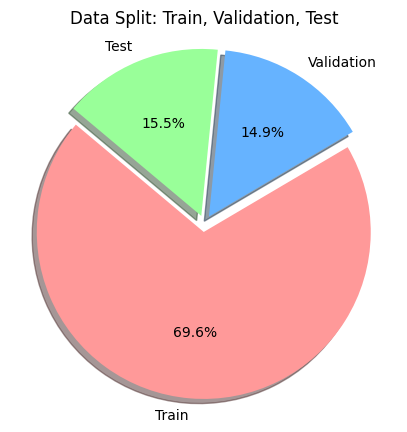

In [16]:
labels = ['Train', 'Validation', 'Test']
sizes = [len(train_dataset), len(val_dataset), len(test_dataset)]
colors = ['#ff9999','#66b3ff','#99ff99']
explode = (0.05, 0.05, 0.05)  # Explode a slice if desired

plt.figure(figsize=(5, 5))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data Split: Train, Validation, Test')
plt.show()

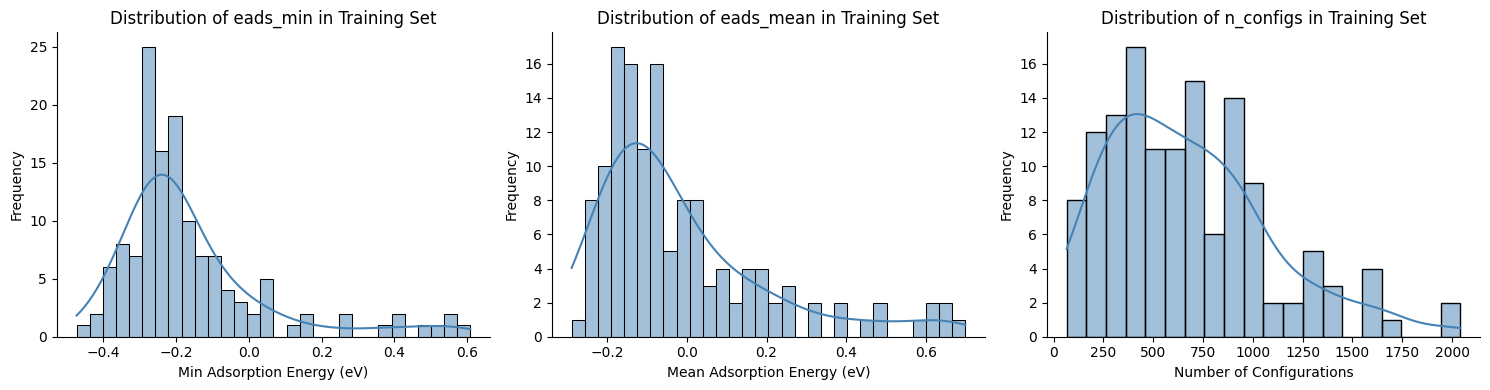

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train_mof_names = [data.mof_name for data in train_dataset]
df_train_labels = df[df['mof_name'].isin(train_mof_names)].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

plot_configs = {
    'eads_min':   {'discrete': False, 'bins': 30, 'label': 'Min Adsorption Energy (eV)'},
    'eads_mean':  {'discrete': False, 'bins': 30, 'label': 'Mean Adsorption Energy (eV)'},
   # 'nco2_max':   {'discrete': True,  'bins': None, 'label': 'Max CO₂ Molecules'},
    'n_configs':  {'discrete': False, 'bins': 20, 'label': 'Number of Configurations'},
}

for ax, (col, cfg) in zip(axes, plot_configs.items()):
    if cfg['discrete']:
        # show each integer value as its own bar
        counts = df_train_labels[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
        ax.set_xlabel(cfg['label'])
        ax.set_ylabel('Count')
    else:
        sns.histplot(df_train_labels[col], bins=cfg['bins'], kde=True, ax=ax, color='steelblue')
        ax.set_xlabel(cfg['label'])
        ax.set_ylabel('Frequency')

    ax.set_title(f'Distribution of {col} in Training Set')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
print(df_train_labels['nco2_max'].value_counts())

nco2_max
1    135
Name: count, dtype: int64


The variables eads_min, eads_mean, and n_configs all exhibit right‑skewed distributions, meaning most MOFs cluster around lower adsorption energies or fewer sampled configurations.

Additionally, nco2_max is equal to 1 for all structures, ensuring that each MOF is evaluated only for the adsorption of a single CO₂ molecule, which mimics dilute‑gas, direct‑air‑capture (DAC) conditions.

## Baseline Model: XGBoost

In [19]:
# ── XGBoost Baseline ──────────────────────────────────────────────────────────
# Install if needed (already available on Colab)
# !pip install xgboost scikit-learn -q

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import kendalltau, spearmanr

# ── 1. Build tabular features from graph_data_list ───────────────────────────
# Everything we need is already in the Data objects — no re-reading CIFs needed

def extract_features(dataset):
    rows = []
    for data in dataset:
        name = data.mof_name
        row = df[df['mof_name'] == name].iloc[0]

        n_atoms    = data.num_nodes
        n_edges    = data.num_edges
        avg_degree = data.num_edges / data.num_nodes

        # Use torch operations — avoid numpy entirely here
        atomic_nums = data.x.squeeze().cpu().detach().tolist()  # plain Python list
        atomic_nums_t = data.x.squeeze().cpu().detach()

        unique_vals = torch.unique(atomic_nums_t)
        n_element_types = len(unique_vals)

        def frac(z):
            return (atomic_nums_t == z).sum().item() / n_atoms

        frac_C     = frac(6)
        frac_H     = frac(1)
        frac_N     = frac(7)
        frac_O     = frac(8)
        organic    = {1, 6, 7, 8, 9, 16, 17}
        frac_metal = sum(
            (atomic_nums_t == z).sum().item() / n_atoms
            for z in unique_vals.tolist()
            if int(z) not in organic
        )

        n_configs = row['n_configs']

        rows.append({
            'mof_name':        name,
            'n_atoms':         n_atoms,
            'n_edges':         n_edges,
            'avg_degree':      avg_degree,
            'frac_C':          frac_C,
            'frac_H':          frac_H,
            'frac_N':          frac_N,
            'frac_O':          frac_O,
            'frac_metal':      frac_metal,
            'n_element_types': n_element_types,
            'n_configs':       n_configs,
            'eads_min':        row['eads_min'],
            'eads_mean':       row['eads_mean'],
        })
    return pd.DataFrame(rows)

df_train = extract_features(train_dataset)
df_val   = extract_features(val_dataset)
df_test  = extract_features(test_dataset)

FEATURE_COLS = ['n_atoms', 'n_edges', 'avg_degree',
                'frac_C', 'frac_H', 'frac_N', 'frac_O', 'frac_metal',
                'n_element_types', 'n_configs']

X_train, y_train = df_train[FEATURE_COLS].values, df_train['eads_min'].values
X_val,   y_val   = df_val[FEATURE_COLS].values,   df_val['eads_min'].values
X_test,  y_test  = df_test[FEATURE_COLS].values,  df_test['eads_min'].values

# Compute mean/std from TRAIN ONLY
y_mean = y_train.mean()
y_std  = y_train.std()

# Standardize
y_train_std = ((y_train - y_mean) / y_std) #.view(1,1)
y_val_std   = ((y_val   - y_mean) / y_std) #.view(1,1)
y_test_std  = ((y_test  - y_mean) / y_std) #.view(1,1)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (135, 10) | Val: (29, 10) | Test: (30, 10)


In [20]:
# ── 2. Train XGBoost ──────────────────────────────────────────────────────────

xgb_model = xgb.XGBRegressor(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_lambda        = 1.0,      # L2
    reg_alpha         = 0.1,      # L1
    early_stopping_rounds = 30,
    eval_metric       = 'mae',
    random_state      = 1148,
    n_jobs            = -1,
)

xgb_model.fit(
    X_train, y_train_std,
    eval_set=[(X_val, y_val_std)],
    verbose=50,
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

[0]	validation_0-mae:0.61173
[31]	validation_0-mae:0.64845

Best iteration: 1


In [21]:
# ── 3. Metrics helper — reuse this for every model ───────────────────────────

def compute_metrics(y_true, y_pred, model_name, split='test'):
    mae      = np.mean(np.abs(y_true - y_pred))
    rmse     = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r2       = r2_score(y_true, y_pred)
    tau, _   = kendalltau(y_true, y_pred)
    rho, _   = spearmanr(y_true, y_pred)

    return {
        'model':   model_name,
        'split':   split,
        'MAE':     round(mae,  4),
        'RMSE':    round(rmse, 4),
        'R2':      round(r2,   4),
        'Kendall': round(tau,  4),
        'Spearman':round(rho,  4),
    }

# ── 4. Shared results store — all models append here ─────────────────────────
# Initialize once; subsequent model cells just call results.append(...)
results = []

In [22]:
# ── 5. Evaluate XGBoost + store results ──────────────────────────────────────

xgb_val_pred_std  = xgb_model.predict(X_val)
xgb_val_pred = xgb_val_pred_std * y_std + y_mean #unstandardize

results.append(compute_metrics(y_val,  xgb_val_pred,  'XGBoost', 'val'))

#xgb_test_pred = xgb_model.predict(X_test)
#results.append(compute_metrics(y_test, xgb_test_pred, 'XGBoost', 'test'))

# Quick preview
pd.DataFrame(results)

,model,split,MAE,RMSE,R2,Kendall,Spearman
0,XGBoost,val,0.1277,0.1777,-0.0807,0.0473,0.0823


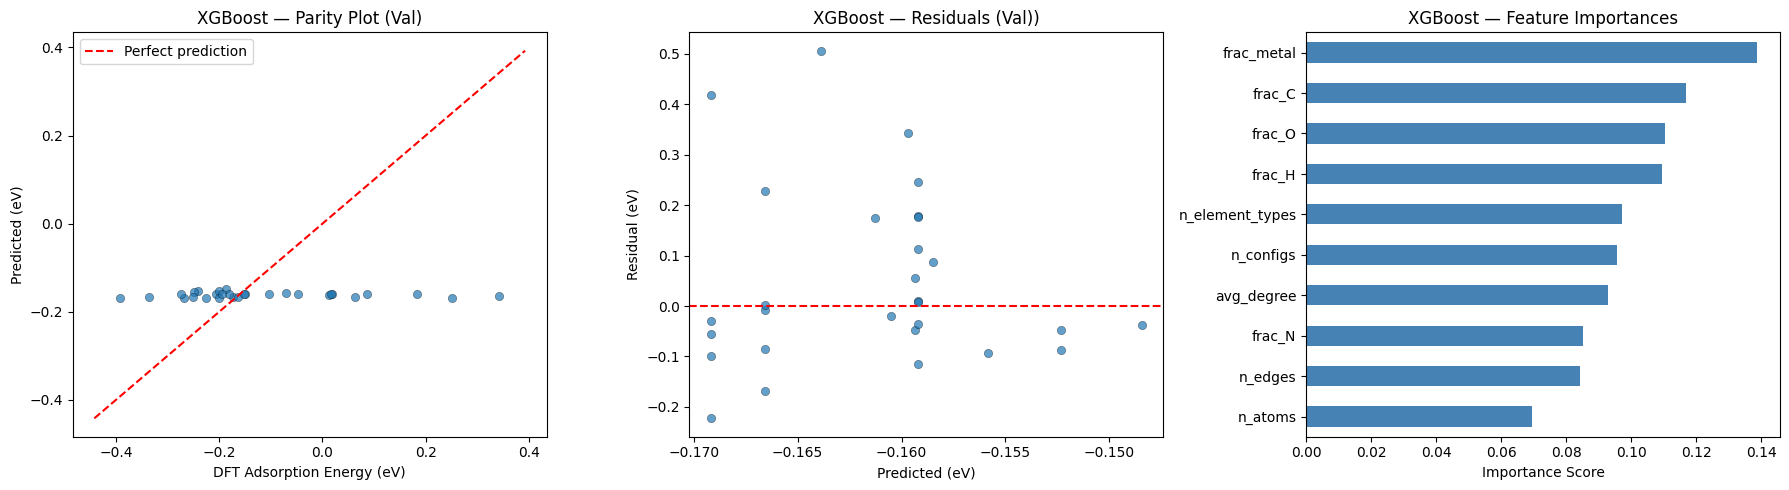

In [23]:
# ── 6. XGBoost diagnostics ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Parity plot
ax = axes[0]
lo = min(y_val.min(), xgb_val_pred.min()) - 0.05
hi = max(y_val.max(), xgb_val_pred.max()) + 0.05
ax.scatter(y_val, xgb_val_pred, alpha=0.7, edgecolors='k', linewidths=0.3)
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('DFT Adsorption Energy (eV)')
ax.set_ylabel('Predicted (eV)')
ax.set_title('XGBoost — Parity Plot (Val)')
ax.legend()

# Residuals
ax = axes[1]
residuals = y_val - xgb_val_pred
ax.scatter(xgb_val_pred, residuals, alpha=0.7, edgecolors='k', linewidths=0.3)
ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted (eV)')
ax.set_ylabel('Residual (eV)')
ax.set_title('XGBoost — Residuals (Val))')

# Feature importances
ax = axes[2]
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Feature Importances')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

**Parity plot:** the predictions are almost a flat horizontal line around -0.18 eV regardless of the true value. XGBoost is essentially just predicting the mean of the training set for every MOF. It has no ability to distinguish MOFs that bind strongly (−0.4 eV) from those that barely bind (+0.3 eV).

**Residuals:** the compressed x-axis range (−0.19 to −0.13 eV) confirms this. All predictions are clustered in a tiny window while the true values span nearly 0.8 eV. The residuals grow systematically as you move away from the mean, a classic sign that the model has no real predictive signal.

**Feature importances:** this is the most interesting panel. frac_metal and frac_N are the top features. Metal fraction relates to the number and type of binding sites and nitrogen often appears in linkers that coordinate CO₂. But even these chemically meaningful features aren't enough because they can't capture where the metal sits or how the pore is shaped.

The reason n_element_types scores lowest due to being the most abstract feature thereby carrying the least structural information.

XGBoost achieves near-constant predictions collapsing to the training mean, confirming that bulk compositional descriptors carry insufficient geometric information to distinguish adsorption sites. This motivates the use of GNNs that operate directly on the 3D atomic graph.

## Graph Neural Network (GNN) Architecture

The initial GNN uses:
- An embedding layer to convert atomic numbers into learnable feature vectors
- An 8‑layer GCN stack with residual connections to stabilize message passing across deep graph layers.
- The first layer includes a projection step to align dimensions for the residual path, while the remaining layers operate in a consistent hidden space.
- After node‑level processing, a global mean pooling layer aggregates information into a graph‑level representation, which is passed through a two‑layer MLP head to produce the final adsorption‑energy prediction.
- The model processes node features (atomic numbers) and edge indices, and output a prediction for `eads_min`.

In [24]:
class GNNModel(nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        super(GNNModel, self).__init__()

        # Embedding for atomic numbers
        self.embedding = nn.Embedding(
            num_embeddings=120,
            embedding_dim=num_node_features
        )

        # Projection for first residual (64 → 128)
        self.input_proj = nn.Linear(num_node_features, hidden_channels)

        # 8 GCN layers
        self.convs = nn.ModuleList([
            GCNConv(num_node_features, hidden_channels),   # layer 1
            GCNConv(hidden_channels, hidden_channels),     # layer 2
            GCNConv(hidden_channels, hidden_channels),     # layer 3
            GCNConv(hidden_channels, hidden_channels),     # layer 4
            GCNConv(hidden_channels, hidden_channels),     # layer 5
            GCNConv(hidden_channels, hidden_channels),     # layer 6
            GCNConv(hidden_channels, hidden_channels),     # layer 7
            GCNConv(hidden_channels, hidden_channels)      # layer 8
        ])

        # MLP head
        self.lin1 = nn.Linear(hidden_channels, hidden_channels // 2)
        #self.lin2 = nn.Linear(hidden_channels // 2, 2)
        self.lin2 = nn.Linear(hidden_channels // 2, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Embedding lookup
        x = x.squeeze(-1)
        x = self.embedding(x)

        # First GCN layer (needs projection for residual)
        x_res = self.input_proj(x)                     # project 64 → 128
        x = self.convs[0](x, edge_index).relu()
        x = x + x_res                                  # safe residual

        # Remaining 7 layers (dims already match)
        for conv in self.convs[1:]:
            x_res = x
            x = conv(x, edge_index).relu()
            x = x + x_res

        # Global pooling
        x = global_mean_pool(x, batch)

        # MLP head
        x = self.lin1(x).relu()
        x = self.lin2(x)

        return x


In [25]:
#initialize, loss function and optimizer
num_node_features = 64 # Dimension for node embeddings
hidden_channels = 128 # Hidden channels in GCNConv layers
set_seed(SEED)

model = GNNModel(num_node_features=num_node_features, hidden_channels=hidden_channels)
#loss_fn = nn.MSELoss() # Mean Squared Error for regression
loss_fn = nn.L1Loss() #MAE

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



### Training and Evaluation


In [26]:
def train(model, optimizer, loss_fn, data_loader):
    model.train() # Set model to training mode
    total_loss = 0
    for data in data_loader:
        optimizer.zero_grad() # Zero gradients
        out = model(data) # Perform forward pass
        loss = loss_fn(out, data.y) # Calculate loss
        loss.backward() # Perform backward pass
        optimizer.step() # Update model parameters
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(data_loader.dataset)

def evaluate(model, loss_fn, data_loader):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    with torch.no_grad(): # Disable gradient calculations
        for data in data_loader:
            out = model(data) # Perform forward pass
            loss = loss_fn(out, data.y) # Calculate loss
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(data_loader.dataset)


Target scaling is essential because the raw adsorption energies span a wide numerical range, and standardizing them ensures that the GCN and EGNN models train on a stable, normalized target distribution. This prevents the loss from being dominated by large‑magnitude values, improves gradient behavior, accelerates convergence, and makes the learning process more numerically stable across all splits.

In [27]:
# ── Standardize y for GCN / EGNN (single target) ─────────────────────────────

# Extract all training targets (each d.y is shape [1] or [1,1])
y_train_tensor = torch.stack([d.y.view(-1) for d in train_dataset])   # shape [N]

# Compute mean and std (scalars)
y_mean = y_train_tensor.mean()
y_std  = y_train_tensor.std()

print("y_mean:", y_mean.item())
print("y_std:", y_std.item())

# Function to apply scaling to a dataset
def scale_dataset(dataset, y_mean, y_std):
    for d in dataset:
        # ensure shape [1,1] for model compatibility
        d.y = ((d.y.view(-1) - y_mean) / y_std).view(1, 1)

# Apply scaling to ALL splits
scale_dataset(train_dataset, y_mean, y_std)
scale_dataset(val_dataset,   y_mean, y_std)
scale_dataset(test_dataset,  y_mean, y_std)

# ── DataLoaders ──────────────────────────────────────────────────────────────
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
# test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


y_mean: -0.15851372480392456
y_std: 0.2098417729139328


In [28]:
epochs = 100 # Define the number of epochs

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train(model, optimizer, loss_fn, train_loader)
    val_loss = evaluate(model, loss_fn, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch: {epoch+1:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# Final evaluation on the test set
#test_loss = evaluate(model, loss_fn, test_loader)
#print(f'\nTest Loss: {test_loss:.4f}')

Epoch: 001, Train Loss: 1.8422, Val Loss: 0.8783
Epoch: 002, Train Loss: 0.8260, Val Loss: 0.8302
Epoch: 003, Train Loss: 0.6466, Val Loss: 0.6469
Epoch: 004, Train Loss: 0.6767, Val Loss: 0.6658
Epoch: 005, Train Loss: 0.6291, Val Loss: 0.7230
Epoch: 006, Train Loss: 0.6190, Val Loss: 0.6267
Epoch: 007, Train Loss: 0.6232, Val Loss: 0.6529
Epoch: 008, Train Loss: 0.6281, Val Loss: 0.7466
Epoch: 009, Train Loss: 0.6156, Val Loss: 0.6198
Epoch: 010, Train Loss: 0.6096, Val Loss: 0.6362
Epoch: 011, Train Loss: 0.5938, Val Loss: 0.6273
Epoch: 012, Train Loss: 0.6045, Val Loss: 0.6812
Epoch: 013, Train Loss: 0.5982, Val Loss: 0.6544
Epoch: 014, Train Loss: 0.5902, Val Loss: 0.6673
Epoch: 015, Train Loss: 0.5857, Val Loss: 0.6744
Epoch: 016, Train Loss: 0.5797, Val Loss: 0.6460
Epoch: 017, Train Loss: 0.5706, Val Loss: 0.6308
Epoch: 018, Train Loss: 0.5645, Val Loss: 0.6469
Epoch: 019, Train Loss: 0.5524, Val Loss: 0.6772
Epoch: 020, Train Loss: 0.5627, Val Loss: 0.6570
Epoch: 021, Train Lo

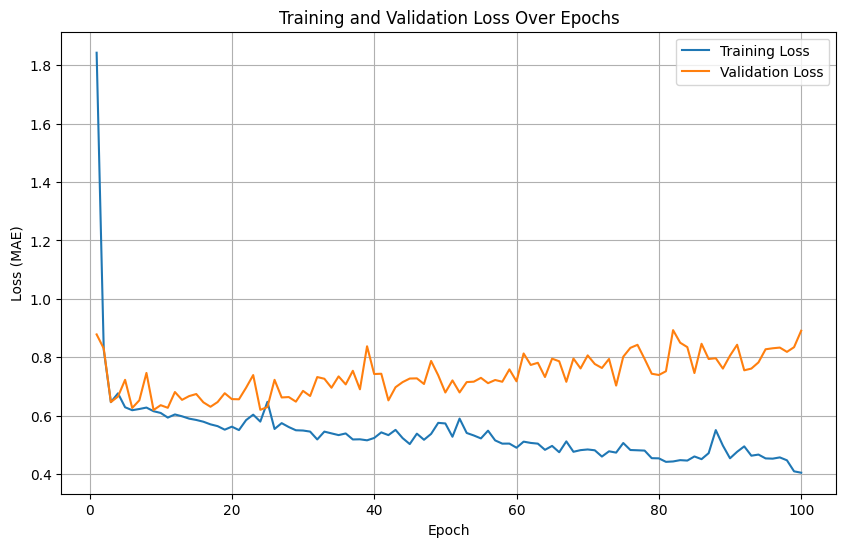

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
def collect_predictions(model, loader, y_mean, y_std):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for data in loader:
            out = model(data) #standardized predictions
            out = out * y_std + y_mean #unstandardize predictions
            y = data.y * y_std + y_mean # unstandardize targets

            preds.append(out.cpu())
            targets.append(y.cpu())

    preds   = torch.cat(preds,   dim=0).tolist()
    targets = torch.cat(targets, dim=0).tolist()
    return np.array(preds), np.array(targets)

gcn_val_preds,  gcn_val_targets  = collect_predictions(model, val_loader, y_mean, y_std)
#gcn_test_preds, gcn_test_targets = collect_predictions(model, test_loader)

# eads_min is column 0
#results.append(compute_metrics(gcn_val_targets[:,0],  gcn_val_preds[:,0],  'GCN', 'val'))
results.append(compute_metrics(gcn_val_targets,  gcn_val_preds,  'GCN', 'val'))

#results.append(compute_metrics(gcn_test_targets[:,0], gcn_test_preds[:,0], 'GCN', 'test'))

pd.DataFrame(results)

,model,split,MAE,RMSE,R2,Kendall,Spearman
0,XGBoost,val,0.1277,0.1777,-0.0807,0.0473,0.0823
1,GCN,val,0.1870,0.2377,-0.9321,0.0000,-0.0113


- From the decreasing training loss, the simple GCN did learn a usable representation of the MOF graphs
- But its validation loss plateaued early and never matched the training curve, signalling that the model was underfitting the underlying structure–property relationship.

- The GCN reaches an MAE of 0.187 and even produces a negative R², meaning it performs worse than predicting the mean adsorption energy.
- In contrast, XGBoost achieved a lower MAE (0.128) and a slightly better (though still weak) R², indicating that the shallow GCN architecture needs to be improved to compare to the tree-based model



To improve the baseline GNN model, we will implement the following:

* Early Stopping: stops the model if validation loss stops improving for a certain number of epochs, preventing further overfitting

* Regularization: use dropout layers within the GNN model or L2 regularization to the optimizer to penalize large weights and reduce complexity

* Alternative GNN Architectures: Explore other GNN architectures like EGNN, which might be more suitable for this specific dataset and task.




## GNN Improved


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_add_pool, global_max_pool
from torch_geometric.nn import BatchNorm

class ImprovedGNNModel(nn.Module):
    def __init__(self, num_node_features=64, hidden_channels=128, dropout=0.3):
        super().__init__()

        # Embedding for atomic numbers
        self.embedding = nn.Embedding(
            num_embeddings=120,
            embedding_dim=num_node_features
        )

        # Projection for first residual (64 → 128)
        self.input_proj = nn.Linear(num_node_features, hidden_channels)

        # 8 GCN layers -> 6 layers
        self.convs = nn.ModuleList([
            GCNConv(num_node_features, hidden_channels),   # layer 1
            GCNConv(hidden_channels, hidden_channels),     # layer 2
            GCNConv(hidden_channels, hidden_channels),     # layer 3
            GCNConv(hidden_channels, hidden_channels),     # layer 4
            GCNConv(hidden_channels, hidden_channels),     # layer 5
            GCNConv(hidden_channels, hidden_channels)     # layer 6
           # GCNConv(hidden_channels, hidden_channels),     # layer 7
           # GCNConv(hidden_channels, hidden_channels)      # layer 8
        ])

        # BatchNorm for each layer
        self.bns = nn.ModuleList([
            BatchNorm(hidden_channels) for _ in range(8)
        ])

        self.dropout = nn.Dropout(dropout)

        # Pooling: mean + variance (2 × hidden_channels)
        self.lin1 = nn.Linear(hidden_channels * 2, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, hidden_channels // 2)
        #self.lin3 = nn.Linear(hidden_channels // 2, 2)  # eads_min, eads_mean
        self.lin3 = nn.Linear(hidden_channels // 2, 1)  # eads_min


    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Embedding lookup
        x = self.embedding(x.squeeze(-1))

        # First layer (needs projection for residual)
        x_res = self.input_proj(x)
        x = self.convs[0](x, edge_index)
        x = self.bns[0](x)
        x = F.relu(x) + x_res
        x = self.dropout(x)

        # Layers 2–8 (residuals match automatically)
        """for i in range(1, 8):
            x_res = x
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x) + x_res
            x = self.dropout(x)"""

        for i in range(1, len(self.convs)):
            x_res = x
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x) + x_res
            x = self.dropout(x)


        # ── Variance pooling ───────────────────────────────────────────────
        x_mean = global_mean_pool(x, batch)
        x_sq_mean = global_mean_pool(x * x, batch)
        x_var = x_sq_mean - x_mean * x_mean  # Var = E[x²] − (E[x])²

        # Concatenate mean + variance
        x = torch.cat([x_mean, x_var], dim=-1)

        # MLP head
        x = F.relu(self.lin1(x))
        x = self.dropout(x)
        x = F.relu(self.lin2(x))
        x = self.lin3(x)

        return x


In [32]:
# ── Early Stopping ────────────────────────────────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=30, min_delta=1e-4, checkpoint_path='best_gcn.pt'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.checkpoint = checkpoint_path
        self.counter    = 0
        self.best_loss  = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.checkpoint)  # save best weights
        else:
            self.counter += 1

        return self.counter >= self.patience  # True = stop training

In [33]:
# ── Initialise Model, Optimizer, Scheduler ───────────────────────────────────

set_seed(SEED)

improved_model = ImprovedGNNModel(
    num_node_features = 64,
    hidden_channels   = 128,
    dropout           = 0.3,
)

# L2 regularization via weight_decay
optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr           = 3e-4,       # lower than original 1e-3 — fixes the val spikes
    weight_decay = 1e-4,       # L2
)

# Cosine annealing — smoothly decays LR, removes need to manually tune schedule
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = 200,   # max epochs
    eta_min= 1e-6,
)

loss_fn      = nn.L1Loss()   # MAE loss — more robust than MSE for this task
early_stop   = EarlyStopping(patience=30, checkpoint_path='best_gcn.pt')

print(f"Parameters: {sum(p.numel() for p in improved_model.parameters()):,}")

Parameters: 150,145


### Training and Evaluation

In [34]:
# ── Training Loop ─────────────────────────────────────────────────────────────

def train_epoch(model, optimizer, loss_fn, loader):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        out  = model(data) # standardized predictions
        loss = loss_fn(out, data.y) #standardized targets
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def eval_epoch(model, loss_fn, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            out  = model(data) #standardized predictions
            loss = loss_fn(out, data.y) #standardized targets
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

# ── Run Training ──────────────────────────────────────────────────────────────
MAX_EPOCHS = 200

train_losses, val_losses = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_epoch(improved_model, optimizer, loss_fn, train_loader)
    val_loss   = eval_epoch(improved_model,  loss_fn,   val_loader)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    if early_stop(val_loss, improved_model):
        print(f"\nEarly stopping at epoch {epoch}. Best val MAE: {early_stop.best_loss:.4f}")
        break

# Reload best weights before evaluation
improved_model.load_state_dict(torch.load('best_gcn.pt'))
print("Loaded best model weights.")

Epoch 010 | Train MAE: 1.0612 | Val MAE: 0.6023 | LR: 2.98e-04
Epoch 020 | Train MAE: 0.7404 | Val MAE: 0.5820 | LR: 2.93e-04
Epoch 030 | Train MAE: 0.6180 | Val MAE: 0.5896 | LR: 2.84e-04
Epoch 040 | Train MAE: 0.5850 | Val MAE: 0.5830 | LR: 2.71e-04
Epoch 050 | Train MAE: 0.5144 | Val MAE: 0.5819 | LR: 2.56e-04

Early stopping at epoch 50. Best val MAE: 0.5820
Loaded best model weights.


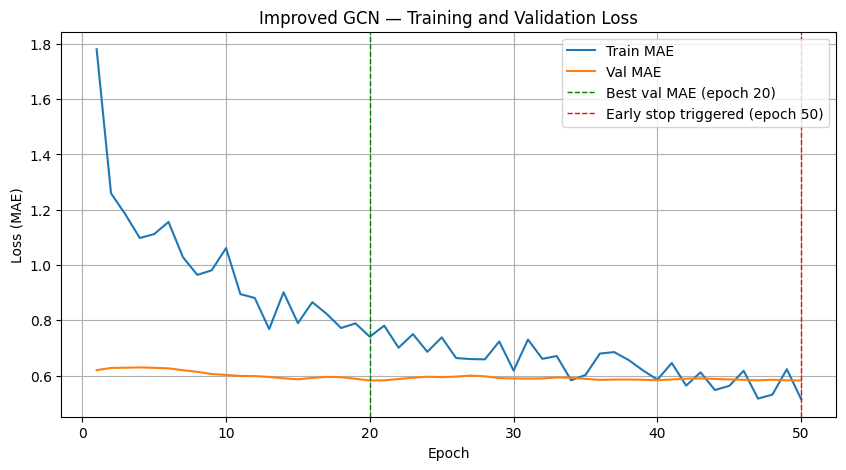

In [35]:
# ── Plot Loss Curve ───────────────────────────────────────────────────────────
stopped_at = len(train_losses)

best_epoch = stopped_at - early_stop.patience

plt.figure(figsize=(10, 5))
plt.plot(range(1, stopped_at + 1), train_losses, label='Train MAE')
plt.plot(range(1, stopped_at + 1), val_losses,   label='Val MAE')
plt.axvline(x=best_epoch,
            color='green', linestyle='--', linewidth=1, label=f'Best val MAE (epoch {best_epoch})')
plt.axvline(x=stopped_at,
            color='red', linestyle='--', linewidth=1, label=f'Early stop triggered (epoch {stopped_at})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Improved GCN — Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# ── Evaluate + Store Results ──────────────────────────────────────────────────
gcni_val_preds,  gcni_val_targets  = collect_predictions(improved_model, val_loader, y_mean, y_std)
#gcn_test_preds, gcn_test_targets = collect_predictions(improved_model, test_loader)

# eads_min is column 0
#results.append(compute_metrics(gcn_val_targets[:,0],  gcn_val_preds[:,0],  'GCN_improved', 'val'))
results.append(compute_metrics(gcni_val_targets,  gcni_val_preds,  'GCN_improved', 'val'))

#results.append(compute_metrics(gcn_test_targets[:,0], gcn_test_preds[:,0], 'GCN', 'test'))

pd.DataFrame(results)

,model,split,MAE,RMSE,R2,Kendall,Spearman
0,XGBoost,val,0.1277,0.1777,-0.0807,0.0473,0.0823
1,GCN,val,0.1870,0.2377,-0.9321,0.0000,-0.0113
2,GCN_improved,val,0.1221,0.1663,0.0542,0.2217,0.3030


## Equivariant Graphical Neural Network (EGNN) - Max Welling

add some info about this type of model

In [37]:
# ── Cell: Install EGNN ────────────────────────────────────────────────────────
# Run once, then comment out
!pip install egnn-pytorch -q

In [38]:
NUM_RBF = 16
CUTOFF  = 6.0

class EGNNLayer(nn.Module):
    """
    E(n)-Equivariant Graph Neural Network layer.
    Satorras, Hoogeboom & Welling, 2021 — adapted for dense PBC MOF graphs.

    Key fix for dense graphs: coordinate updates are DISABLED (invariant-only mode).
    With 34k+ edges per MOF, updating coordinates causes gradient explosion.
    Node features still use RBF-encoded distances as edge features, preserving E(3) invariance.
    """
    def __init__(self, in_dim, out_dim, num_rbf=NUM_RBF, cutoff=CUTOFF):
        super().__init__()
        self.num_rbf = num_rbf
        self.cutoff  = cutoff

        # Precompute RBF centers — registered as buffer so they move to correct device
        self.register_buffer(
            'rbf_centers',
            torch.linspace(0, cutoff ** 2, num_rbf)  # centers in squared-distance space
        )
        self.rbf_width = (cutoff ** 2 / num_rbf) * 2

        # Message MLP: takes (h_i, h_j, rbf(dist)) → message
        # input size is in_dim * 2 + num_rbf instead of in_dim * 2 + 1
        self.message_mlp = nn.Sequential(
            nn.Linear(in_dim * 2 + num_rbf, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
            nn.SiLU(),
        )

        # Update MLP: takes (h_i, aggregated messages) → h_i'
        self.update_mlp = nn.Sequential(
            nn.Linear(in_dim + out_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
        )

        # Attention gate — downweights distant neighbors (critical for 6A cutoff)
        self.att_mlp = nn.Sequential(
            nn.Linear(out_dim, 1),
            nn.Sigmoid(),
        )

    def rbf(self, dist_sq):
        # dist_sq: [E, 1] — squared distances
        # returns: [E, num_rbf] — Gaussian basis expansion
        return torch.exp(
            -((dist_sq - self.rbf_centers) ** 2) / self.rbf_width
        )

    def forward(self, h, pos, edge_index):
        row, col = edge_index          # row = target i, col = source j

        # Compute pairwise squared distances from positions
        diff    = pos[row] - pos[col]                         # [E, 3]
        dist_sq = diff.pow(2).sum(dim=-1, keepdim=True)       # [E, 1]

        # RBF encode distances — richer representation than single scalar
        dist_rbf = self.rbf(dist_sq)                          # [E, num_rbf]

        # Compute messages using RBF-encoded distances
        m_ij = self.message_mlp(
            torch.cat([h[row], h[col], dist_rbf], dim=-1)
        )                                                      # [E, out_dim]

        # Attention gate — suppress distant noisy edges
        att  = self.att_mlp(m_ij)                             # [E, 1]
        m_ij = m_ij * att                                     # [E, out_dim]

        # Aggregate messages at each node (mean — safer than sum for dense graphs)
        agg = torch.zeros(h.size(0), m_ij.size(-1),
                          device=h.device, dtype=h.dtype)
        agg.scatter_add_(0, edge_index[0].unsqueeze(-1).expand_as(m_ij), m_ij)

        # Mean normalization by node degree
        deg = torch.zeros(h.size(0), device=h.device, dtype=h.dtype)
        deg.scatter_add_(0, edge_index[0],
                         torch.ones(edge_index.size(1), device=h.device, dtype=h.dtype))
        deg = deg.clamp(min=1).unsqueeze(-1)
        agg = agg / deg                                        # [N, out_dim]

        # Update node features
        h_new = self.update_mlp(torch.cat([h, agg], dim=-1))  # [N, out_dim]

        # Return pos unchanged — coordinate updates disabled for dense PBC graphs
        return h_new, pos


In [39]:
class EGNNModel(nn.Module):
    def __init__(self, node_dim=64, hidden_dim=256, dropout=0.2,
                 num_rbf=NUM_RBF, cutoff=CUTOFF):
        super().__init__()

        self.embedding  = nn.Embedding(120, node_dim)
        self.dropout    = nn.Dropout(dropout)
        self.input_proj = nn.Linear(node_dim, hidden_dim)

        # 3 layers — PBC graphs are dense, more layers = oversmoothing
        layers = [EGNNLayer(in_dim=node_dim,   out_dim=hidden_dim,
                            num_rbf=num_rbf, cutoff=cutoff)]
        for _ in range(2):
            layers.append(EGNNLayer(in_dim=hidden_dim, out_dim=hidden_dim,
                                    num_rbf=num_rbf, cutoff=cutoff))
        self.layers = nn.ModuleList(layers)

        # LayerNorm — more stable than BatchNorm for variable-size MOF graphs
        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(3)
        ])

        # Variance pooling → mean + variance = 2 * hidden_dim
        self.lin1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.lin3 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, data):
        h         = self.embedding(data.x.squeeze(-1))
        pos       = data.pos
        edge_index = data.edge_index

        for i, (layer, norm) in enumerate(zip(self.layers, self.norms)):
            h_res    = self.input_proj(h) if i == 0 else h
            h, pos   = layer(h, pos, edge_index)
            h        = norm(h)
            h        = F.relu(h) + h_res
            h        = self.dropout(h)

        # Variance pooling
        h_mean    = global_mean_pool(h, data.batch)
        h_sq_mean = global_mean_pool(h * h, data.batch)
        h_var     = h_sq_mean - h_mean * h_mean

        h = torch.cat([h_mean, h_var], dim=-1)

        # MLP head
        h = F.relu(self.lin1(h))
        h = self.dropout(h)
        h = F.relu(self.lin2(h))
        return self.lin3(h)

In [40]:
# ── Cell: Initialise EGNN ─────────────────────────────────────────────────────

set_seed(SEED)

egnn_model = EGNNModel(
    node_dim   = 64,
    #hidden_dim = 128,
    #n_layers   = 3,
    #dropout    = 0.3,
    dropout    = 0.2,
    num_rbf    = NUM_RBF,
    cutoff     = CUTOFF
)

optimizer_egnn = torch.optim.Adam(
    egnn_model.parameters(),
    lr           = 1e-4, #3e-4,
    weight_decay = 1e-4,    # L2 regularization
)

scheduler_egnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_egnn,
    T_max   = 200,
    eta_min = 1e-6,
)

loss_fn_egnn  = nn.L1Loss()    # MAE — consistent with GCN
early_stop_egnn = EarlyStopping(patience=30, checkpoint_path='best_egnn.pt')

print(f"EGNN parameters: {sum(p.numel() for p in egnn_model.parameters()):,}")

EGNN parameters: 1,238,532


In [41]:
# In your DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [42]:
device = torch.device('cpu')
print(f"Using device: {device}")

egnn_model     = EGNNModel().to(device)
optimizer_egnn = torch.optim.Adam(egnn_model.parameters(), lr=1e-4)
loss_fn_egnn   = nn.L1Loss()  # MAE
scheduler_egnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_egnn, T_max=200, eta_min=1e-6
)

def train_epoch_egnn(model, optimizer, loss_fn, loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = model(data)
        loss = loss_fn(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch_egnn(model, loss_fn, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out  = model(data)
            loss = loss_fn(out, data.y)
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

MAX_EPOCHS = 200
egnn_train_losses, egnn_val_losses = [], []
best_val_loss = float('inf')
patience      = 30
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_epoch_egnn(egnn_model, optimizer_egnn, loss_fn_egnn, train_loader)
    val_loss   = eval_epoch_egnn(egnn_model,  loss_fn_egnn,   val_loader)

    optimizer_egnn.step()   # ensure optimizer steps before scheduler
    scheduler_egnn.step()

    egnn_train_losses.append(train_loss)
    egnn_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(egnn_model.state_dict(), 'best_egnn.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f} | LR: {scheduler_egnn.get_last_lr()[0]:.2e}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}. Best val MAE: {best_val_loss:.4f}")
        break

egnn_model.load_state_dict(torch.load('best_egnn.pt'))
print("Loaded best EGNN weights.")

Using device: cpu
Epoch 010 | Train MAE: 0.6267 | Val MAE: 0.6139 | LR: 9.94e-05
Epoch 020 | Train MAE: 0.6047 | Val MAE: 0.6031 | LR: 9.76e-05
Epoch 030 | Train MAE: 0.5875 | Val MAE: 0.5986 | LR: 9.46e-05
Epoch 040 | Train MAE: 0.5443 | Val MAE: 0.6046 | LR: 9.05e-05
Epoch 050 | Train MAE: 0.5638 | Val MAE: 0.5945 | LR: 8.55e-05
Epoch 060 | Train MAE: 0.5437 | Val MAE: 0.5930 | LR: 7.96e-05
Epoch 070 | Train MAE: 0.4978 | Val MAE: 0.6074 | LR: 7.30e-05

Early stopping at epoch 78. Best val MAE: 0.5713
Loaded best EGNN weights.


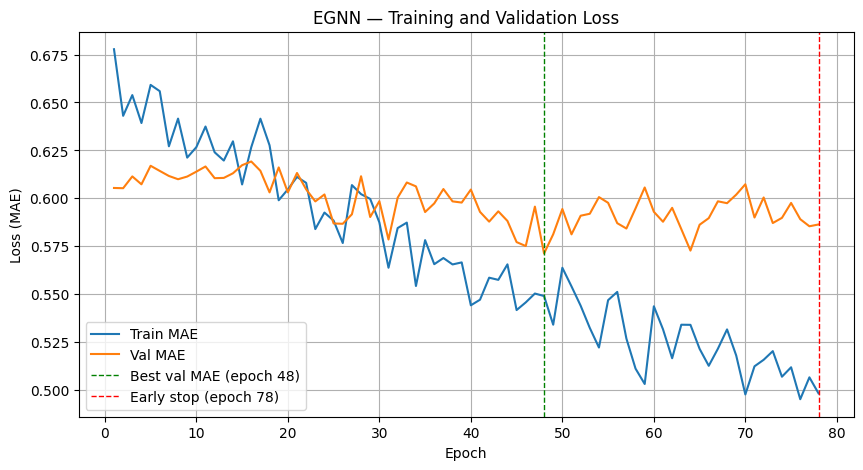

In [43]:
# ── Cell: EGNN Loss Curve ─────────────────────────────────────────────────────

stopped_at  = len(egnn_train_losses)
best_epoch  = stopped_at - early_stop_egnn.patience

plt.figure(figsize=(10, 5))
plt.plot(range(1, stopped_at + 1), egnn_train_losses, label='Train MAE')
plt.plot(range(1, stopped_at + 1), egnn_val_losses,   label='Val MAE')
plt.axvline(x=best_epoch,  color='green', linestyle='--', linewidth=1,
            label=f'Best val MAE (epoch {best_epoch})')
plt.axvline(x=stopped_at,  color='red',   linestyle='--', linewidth=1,
            label=f'Early stop (epoch {stopped_at})')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('EGNN — Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# ── Cell: EGNN Evaluate + Store Results ──────────────────────────────────────

egnn_val_preds,  egnn_val_targets  = collect_predictions(egnn_model, val_loader, y_mean, y_std)
#egnn_test_preds, egnn_test_targets = collect_predictions(egnn_model, test_loader)

#results.append(compute_metrics(egnn_val_targets[:,0],  egnn_val_preds[:,0],  'EGNN', 'val'))
results.append(compute_metrics(egnn_val_targets,  egnn_val_preds,  'EGNN', 'val'))

#results.append(compute_metrics(egnn_test_targets[:,0], egnn_test_preds[:,0], 'EGNN', 'test'))

pd.DataFrame(results)

,model,split,MAE,RMSE,R2,Kendall,Spearman
0,XGBoost,val,0.1277,0.1777,-0.0807,0.0473,0.0823
1,GCN,val,0.1870,0.2377,-0.9321,0.0000,-0.0113
2,GCN_improved,val,0.1221,0.1663,0.0542,0.2217,0.3030
3,EGNN,val,0.1201,0.1834,-0.1508,0.1330,0.1700


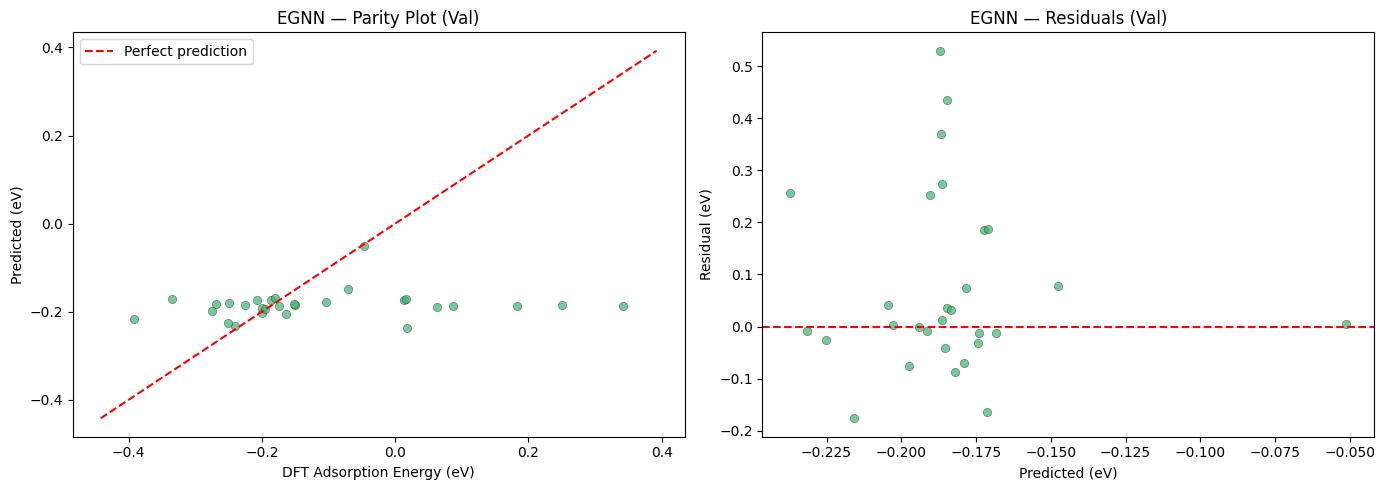

In [45]:
# ── Cell: EGNN Diagnostics ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parity plot
ax = axes[0]
y_true = egnn_val_targets#[:, 0]
y_pred = egnn_val_preds#[:,  0]
lo = min(y_true.min(), y_pred.min()) - 0.05
hi = max(y_true.max(), y_pred.max()) + 0.05
ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='k', linewidths=0.3, color='mediumseagreen')
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('DFT Adsorption Energy (eV)')
ax.set_ylabel('Predicted (eV)')
ax.set_title('EGNN — Parity Plot (Val)')
ax.legend()

# Residuals
ax = axes[1]
residuals = y_true - y_pred
ax.scatter(y_pred, residuals, alpha=0.7, edgecolors='k', linewidths=0.3, color='mediumseagreen')
ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted (eV)')
ax.set_ylabel('Residual (eV)')
ax.set_title('EGNN — Residuals (Val)')

plt.tight_layout()
plt.show()

The EGNN layer updates both h (node features) and pos (atomic positions) simultaneously. The position update uses the direction vectors between neighboring atoms weighted by a learned scalar — this is what gives it E(3)-equivariance without needing spherical harmonics. The GCN only updates node features and ignores the actual 3D coordinates beyond using them to build the initial edge index, which is why the EGNN should outperform it — it uses the full geometric information at every layer, not just at graph construction time.

# Run at the end

test metrics final comparison + graph



In [48]:
# ── Final Model Comparison ────────────────────────────────────────────────────

# Ensure all models are in eval mode
model.eval()              # original GCN
improved_model.eval()     # improved GCN
egnn_model.eval()         # EGNN

# Test loader
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ── XGBoost (already unstandardized) ─────────────────────────────────────────
xgb_test_preds  = xgb_model.predict(X_test)
xgb_test_labels = df_test['eads_min'].values

# ── Original GCN predictions ─────────────────────────────────────────────────
orig_test_preds, orig_test_targets = collect_predictions(
    model, test_loader, y_mean, y_std
)

# ── Improved GCN predictions ─────────────────────────────────────────────────
improved_test_preds, improved_test_targets = collect_predictions(
    improved_model, test_loader, y_mean, y_std
)

# ── EGNN predictions ─────────────────────────────────────────────────────────
egnn_test_preds, egnn_test_targets = collect_predictions(
    egnn_model, test_loader, y_mean, y_std
)

# ── Compute metrics for all four models ──────────────────────────────────────
final_results = [
    compute_metrics(xgb_test_labels,           xgb_test_preds,          'XGBoost',        'test'),
    compute_metrics(orig_test_targets,         orig_test_preds,         'GCN (original)', 'test'),
    compute_metrics(improved_test_targets,     improved_test_preds,     'GCN (improved)', 'test'),
    compute_metrics(egnn_test_targets,         egnn_test_preds,         'EGNN',           'test'),
]

df_final = pd.DataFrame(final_results)

print("=" * 70)
print("FINAL MODEL COMPARISON — TEST SET")
print("=" * 70)
print(df_final.to_string(index=False))
print()
print("DFT uncertainty baseline:  MAE ≈ 0.05–0.10 eV")
print("Kendall τ target:          τ ≥ 0.75  (reliable MOF ranking)")


FINAL MODEL COMPARISON — TEST SET
         model split    MAE   RMSE      R2  Kendall  Spearman
       XGBoost  test 0.3124 0.3624 -1.0813   0.0286    0.0395
GCN (original)  test 0.2110 0.3283 -0.7080  -0.1632   -0.2120
GCN (improved)  test 0.1960 0.2829 -0.2685  -0.1632   -0.2454
          EGNN  test 0.1670 0.2685 -0.1423   0.0437    0.0919

DFT uncertainty baseline:  MAE ≈ 0.05–0.10 eV
Kendall τ target:          τ ≥ 0.75  (reliable MOF ranking)


In [49]:
import numpy as np
from scipy import stats

def bootstrap_ci(y_true, y_pred, metric_fn, n_bootstrap=1000, ci=95):
    """
    Compute bootstrap confidence interval for a scalar metric.
    metric_fn: takes (y_true, y_pred) → scalar
    """
    n = len(y_true)
    scores = []
    rng = np.random.default_rng(42)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        scores.append(metric_fn(y_true[idx], y_pred[idx]))
    scores = np.array(scores)
    lo = np.percentile(scores, (100 - ci) / 2)
    hi = np.percentile(scores, 100 - (100 - ci) / 2)
    return lo, hi

def compute_metrics_with_ci(y_true, y_pred, model_name, split, n_bootstrap=1000):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from scipy.stats import kendalltau, spearmanr

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Point estimates
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    r2       = r2_score(y_true, y_pred)
    kendall  = kendalltau(y_true, y_pred).statistic
    spearman = spearmanr(y_true, y_pred).statistic

    # Bootstrap CIs
    mae_lo,  mae_hi  = bootstrap_ci(y_true, y_pred,
                           lambda a, b: mean_absolute_error(a, b), n_bootstrap)
    rmse_lo, rmse_hi = bootstrap_ci(y_true, y_pred,
                           lambda a, b: np.sqrt(mean_squared_error(a, b)), n_bootstrap)
    r2_lo,   r2_hi   = bootstrap_ci(y_true, y_pred,
                           lambda a, b: r2_score(a, b), n_bootstrap)
    kt_lo,   kt_hi   = bootstrap_ci(y_true, y_pred,
                           lambda a, b: kendalltau(a, b).statistic, n_bootstrap)
    sp_lo,   sp_hi   = bootstrap_ci(y_true, y_pred,
                           lambda a, b: spearmanr(a, b).statistic, n_bootstrap)

    return {
        'model':   model_name,
        'split':   split,
        'MAE':     f"{mae:.4f} [{mae_lo:.4f}, {mae_hi:.4f}]",
        'RMSE':    f"{rmse:.4f} [{rmse_lo:.4f}, {rmse_hi:.4f}]",
        'R2':      f"{r2:.4f} [{r2_lo:.4f}, {r2_hi:.4f}]",
        'Kendall': f"{kendall:.4f} [{kt_lo:.4f}, {kt_hi:.4f}]",
        'Spearman':f"{spearman:.4f} [{sp_lo:.4f}, {sp_hi:.4f}]",
    }

# ── Final Model Comparison with Bootstrap CIs ─────────────────────────────────
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xgb_test_preds  = xgb_model.predict(X_test)
xgb_test_labels = df_test['eads_min'].values

orig_test_preds,     orig_test_targets     = collect_predictions(model,          test_loader, y_mean, y_std)
improved_test_preds, improved_test_targets = collect_predictions(improved_model, test_loader, y_mean, y_std)
egnn_test_preds,     egnn_test_targets     = collect_predictions(egnn_model,     test_loader, y_mean, y_std)

final_results = [
    compute_metrics_with_ci(xgb_test_labels,       xgb_test_preds,       'XGBoost',        'test'),
    compute_metrics_with_ci(orig_test_targets,      orig_test_preds,      'GCN (original)', 'test'),
    compute_metrics_with_ci(improved_test_targets,  improved_test_preds,  'GCN (improved)', 'test'),
    compute_metrics_with_ci(egnn_test_targets,      egnn_test_preds,      'EGNN',           'test'),
]

df_final = pd.DataFrame(final_results)

print("=" * 90)
print("FINAL MODEL COMPARISON — TEST SET (95% Bootstrap CI, n=1000)")
print("=" * 90)
print(df_final.to_string(index=False))
print()
print("DFT uncertainty baseline:  MAE ≈ 0.05–0.10 eV")
print("Kendall τ target:          τ ≥ 0.75  (reliable MOF ranking)")

FINAL MODEL COMPARISON — TEST SET (95% Bootstrap CI, n=1000)
         model split                     MAE                    RMSE                          R2                   Kendall                  Spearman
       XGBoost  test 0.3124 [0.2557, 0.3920] 0.3624 [0.2687, 0.4821] -1.0813 [-13.6002, -0.4043]  0.0286 [-0.2471, 0.2820]  0.0395 [-0.3466, 0.3869]
GCN (original)  test 0.2110 [0.1315, 0.3118] 0.3283 [0.1780, 0.4832]  -0.7080 [-4.0994, -0.3435] -0.1632 [-0.4225, 0.1053] -0.2120 [-0.5545, 0.1851]
GCN (improved)  test 0.1960 [0.1351, 0.2781] 0.2829 [0.1598, 0.4156]  -0.2685 [-3.5445, -0.0661] -0.1632 [-0.3934, 0.1017] -0.2454 [-0.5537, 0.1310]
          EGNN  test 0.1670 [0.1027, 0.2537] 0.2685 [0.1314, 0.4003]  -0.1423 [-1.8374, -0.0190]  0.0437 [-0.1587, 0.2483]  0.0919 [-0.2388, 0.3948]

DFT uncertainty baseline:  MAE ≈ 0.05–0.10 eV
Kendall τ target:          τ ≥ 0.75  (reliable MOF ranking)


/tmp/ipykernel_19105/749686840.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_final['model'], rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_19105/749686840.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_final['model'], rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_19105/749686840.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_final['model'], rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_19105/749686840.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_final['model'], rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_19105/7496868

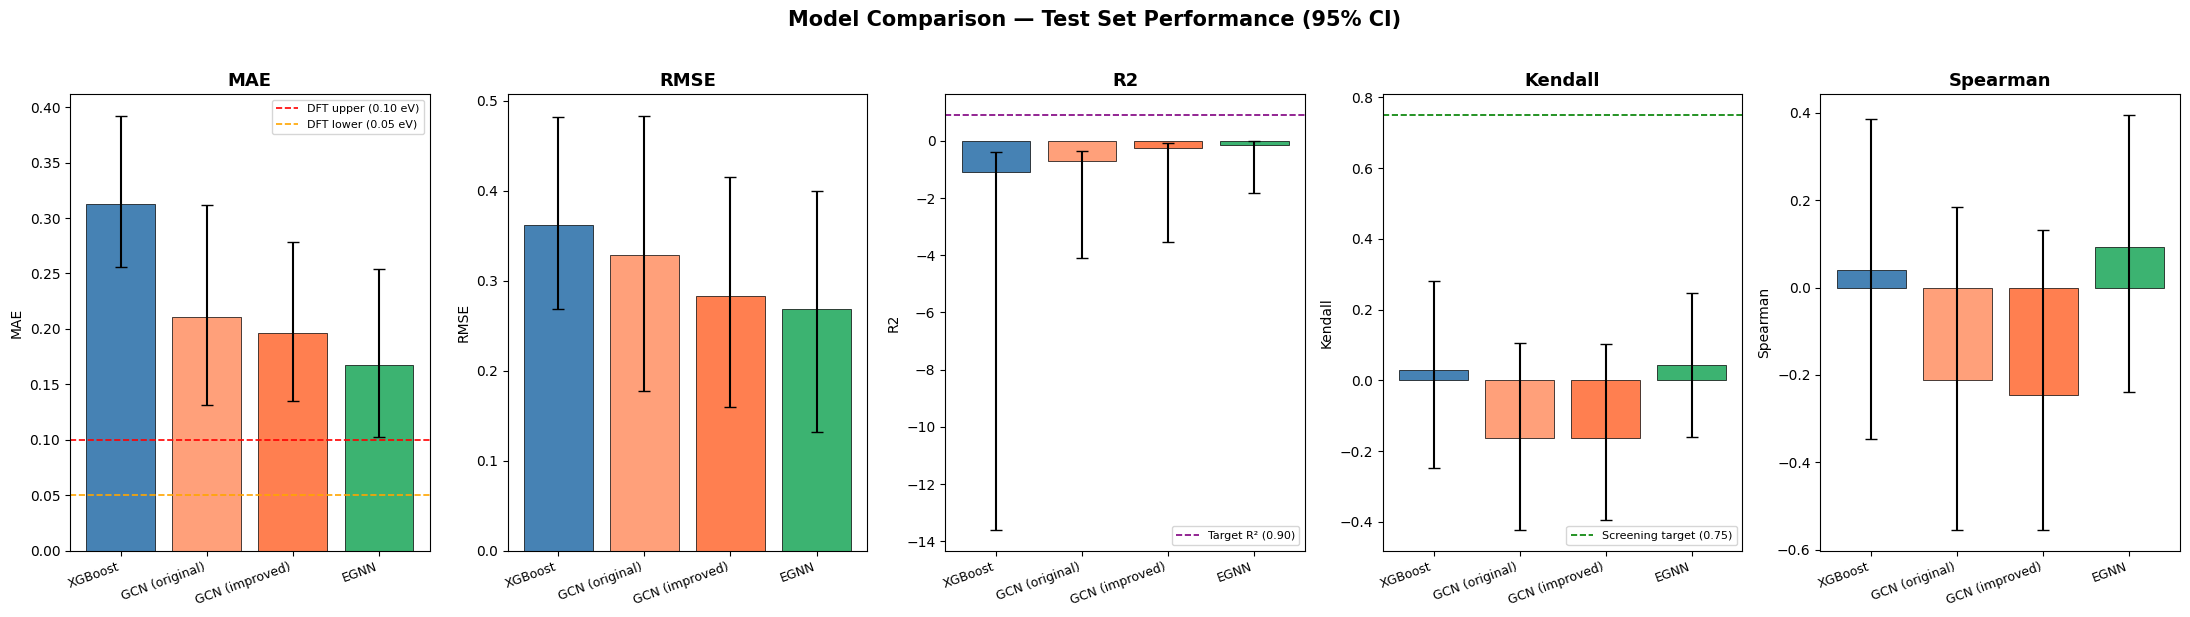

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics_to_plot = ['MAE', 'RMSE', 'R2', 'Kendall', 'Spearman']

colors = {
    'XGBoost':        'steelblue',
    'GCN (original)': 'lightsalmon',
    'GCN (improved)': 'coral',
    'EGNN':           'mediumseagreen',
}

def parse_ci(ci_string):
    """
    Convert '0.0831 [0.0724, 0.0942]' → (0.0831, 0.0724, 0.0942)
    """
    point, interval = ci_string.split('[')
    lo, hi = interval[:-1].split(',')
    return float(point), float(lo), float(hi)

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 6))

for ax, metric in zip(axes, metrics_to_plot):

    for _, row in df_final.iterrows():
        model = row['model']
        ci_str = row[metric]

        point, lo, hi = parse_ci(ci_str)
        err_low  = point - lo
        err_high = hi - point

        ax.bar(
            model,
            point,
            yerr=[[err_low], [err_high]],
            color=colors.get(model, 'gray'),
            edgecolor='k',
            linewidth=0.5,
            capsize=4,
        )

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(df_final['model'], rotation=20, ha='right', fontsize=9)

    # Reference lines
    if metric == 'MAE':
        ax.axhline(0.10, color='red',    linestyle='--', linewidth=1.2,
                   label='DFT upper (0.10 eV)')
        ax.axhline(0.05, color='orange', linestyle='--', linewidth=1.2,
                   label='DFT lower (0.05 eV)')
        ax.legend(fontsize=8)

    if metric == 'Kendall':
        ax.axhline(0.75, color='green', linestyle='--', linewidth=1.2,
                   label='Screening target (0.75)')
        ax.legend(fontsize=8)

    if metric == 'R2':
        ax.axhline(0.90, color='purple', linestyle='--', linewidth=1.2,
                   label='Target R² (0.90)')
        ax.legend(fontsize=8)

plt.suptitle('Model Comparison — Test Set Performance (95% CI)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


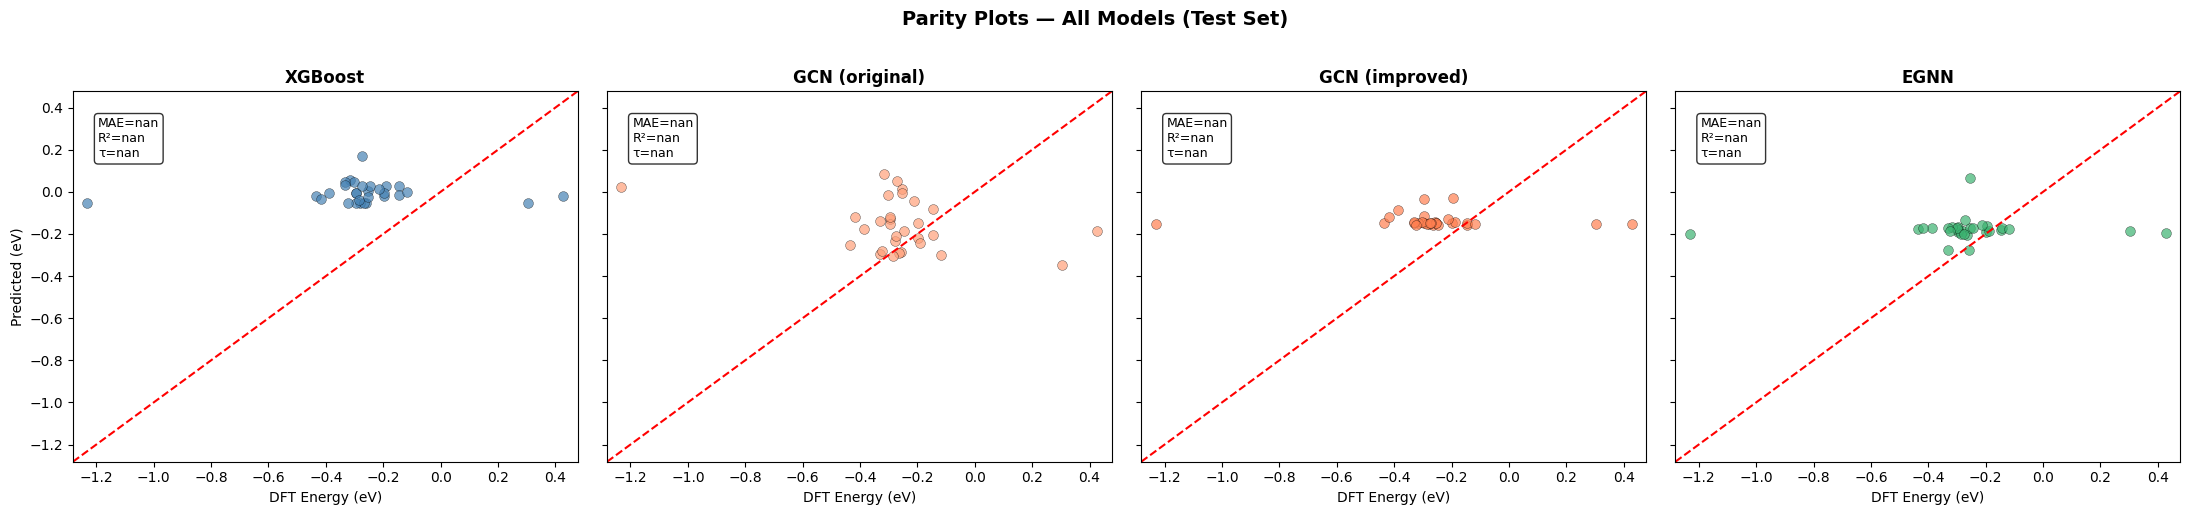

In [54]:
# ── Ensure metrics are numeric ───────────────────────────────────────────────
for col in ['MAE', 'RMSE', 'R2', 'Kendall', 'Spearman']:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# ── Parity Plots Side by Side ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

plot_data = [
    ('XGBoost',        xgb_test_labels,           xgb_test_preds,          'steelblue'),
    ('GCN (original)', orig_test_targets,         orig_test_preds,         'lightsalmon'),
    ('GCN (improved)', improved_test_targets,     improved_test_preds,     'coral'),
    ('EGNN',           egnn_test_targets,         egnn_test_preds,         'mediumseagreen'),
]

for ax, (name, y_true, y_pred, color) in zip(axes, plot_data):

    # Compute plot limits
    lo = min(y_true.min(), y_pred.min()) - 0.05
    hi = max(y_true.max(), y_pred.max()) + 0.05

    # Scatter
    ax.scatter(y_true, y_pred, alpha=0.7, color=color,
               edgecolors='k', linewidths=0.3, s=50)

    # y=x line
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('DFT Energy (eV)')
    ax.set_title(name, fontweight='bold')

    # Metrics annotation
    row = df_final[df_final['model'] == name].iloc[0]
    ax.text(0.05, 0.93,
            f"MAE={row['MAE']:.3f}\nR²={row['R2']:.3f}\nτ={row['Kendall']:.3f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Predicted (eV)')
plt.suptitle('Parity Plots — All Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
